# Use Filtering of Noise

In [ ]:
# Course utilities (do not modify this cell)

from pathlib import Path
import sys

# repo_root/16_06_Class/notebooks → repo_root/16_06_Class
repo_root = Path.cwd().parents[0]
sys.path.insert(0, str(repo_root))

import courseutils.basic_material as bm
import courseutils.control_materials as cm

bm.setup_environment()
cm.setup_environment()

import numpy as np
import matplotlib.pyplot as plt
colors = bm.get_colors()

from scipy.optimize import fsolve


In [6]:
colors = bm.get_colors()

import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

import control as ct
import control.matlab as cmat

import warnings
warnings.filterwarnings(
    "ignore",
    message="divide by zero encountered in divide"
)
warnings.filterwarnings(
    "ignore",
    message="invalid value encountered in divide"
)

## <a id='toc1_6_'></a>[Use filter to avoid high frequency issue with PD](#toc0_)

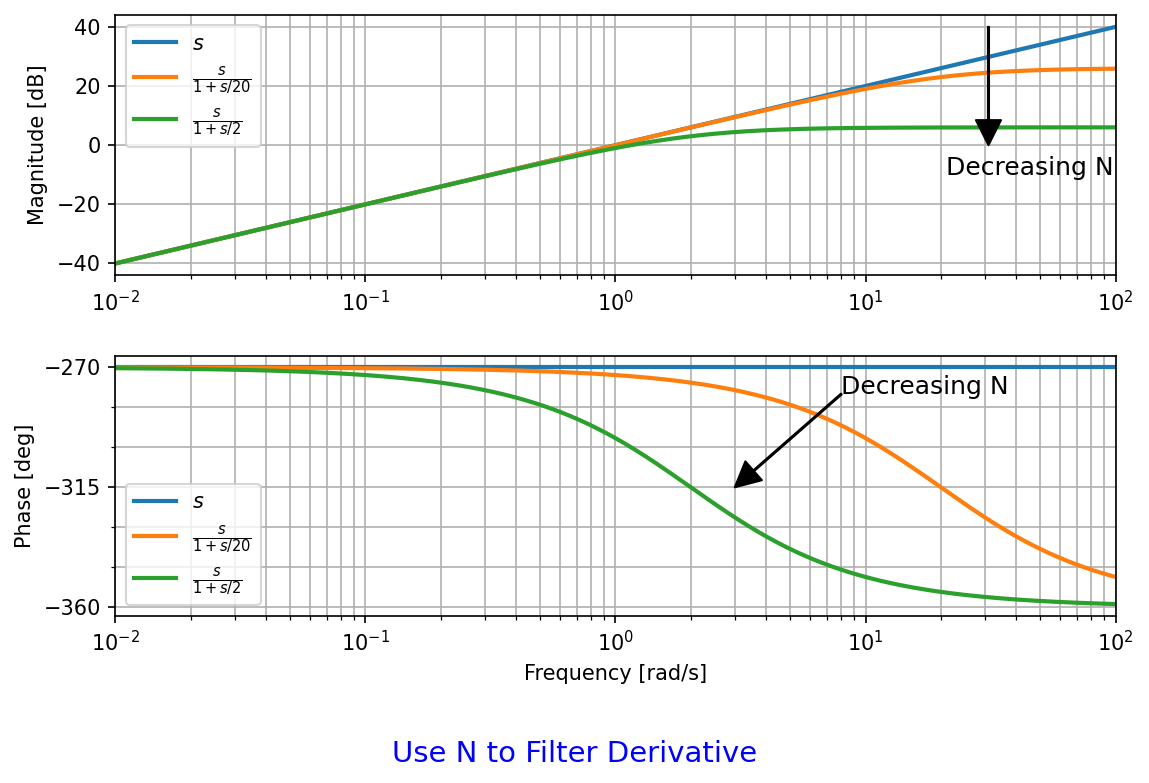

In [7]:
w = np.logspace(-2, 2, 1000)

G_deriv    = ct.tf((1, 0), (0, 1))
G_deriv_2  = ct.tf((1, 0), (1/2, 1))
G_deriv_20 = ct.tf((1, 0), (1/20, 1))

fig, ax = plt.subplots(2, 1, figsize=(8, 5), dpi=150)

# Bode plots (plot-only, no return capture)
ct.bode_plot(G_deriv,    w, ax=ax, label=r'$s$')
ct.bode_plot(G_deriv_20, w, ax=ax, label=r'$\frac{s}{1+s/20}$')
ct.bode_plot(G_deriv_2,  w, ax=ax, label=r'$\frac{s}{1+s/2}$')

ax_mag, ax_phase = ax

# Legends
ax_mag.legend()
ax_phase.legend()

# Annotations
ax_mag.annotate(
    '', xy=(31, 0), xytext=(31, 40),
    arrowprops=dict(facecolor='black', shrink=0., width=0.5),
)
ax_phase.annotate(
    '', xy=(3, -315), xytext=(8, -280),
    arrowprops=dict(facecolor='black', shrink=0., width=0.5),
)

ax_mag.text(21, -10, 'Decreasing N', fontsize=12)
ax_phase.text(8, -280, 'Decreasing N', fontsize=12)

cm.caption("Use N to Filter Derivative", fig)

fig.savefig("./figs/L12_5.pdf", dpi=600)
plt.show()

In [8]:
from scipy.signal import butter, lfilter

f_signal = 5  # Frequency of the signal
HP_freq = 2*f_signal # Cutoff frequency of the high-pass filter
LP_freq = 1.5*f_signal # Cutoff frequency of the low-pass filter
amp_noise = 0.05 # Amplitude of the noise

# Create a time vector
dt = 0.005  # Time step
t = np.arange(0, 6, dt)  # Time vector
N = len(t)  # Number of samples
frequencies = np.fft.fftfreq(N, dt)  # Frequency vector in Hz

# Create a signal (e.g., a sine wave)
signal = np.sin(2 * np.pi * f_signal * t)  # 5 Hz sine wave
dsignal = 2 * np.pi * f_signal * np.cos(2 * np.pi * f_signal * t)
# Design a high-pass filter to add the noise
# If fs is specified, Wn is in the same units as fs.
b, a = butter(N = 6, Wn = HP_freq, btype='high', fs=1/dt)  
# Generate high frequency noise
noise = amp_noise * np.random.randn(len(t))  # Gaussian noise
# Apply the high-pass filter to the noise
filtered_noise = lfilter(b, a, noise)

# Add the filtered noise to the signal
noisy_signal = signal + filtered_noise
#derivative_noisy_signal = np.diff(noisy_signal) / np.diff(t)

## Differentiation Approaches

In [9]:
# Define differentiation filters
class BackwardDifferenceFilter:
    def __init__(self, dt):
        self.dt = dt

    def differentiate(self, y):
        return np.diff(y) / self.dt

class LowPassDifferentiator:
    def __init__(self, dt, cutoff_freq, order=1):
        self.dt = dt
        self.cutoff_freq = cutoff_freq
        self.order = order
        self.b, self.a = butter(order, cutoff_freq, btype='low', fs=1/dt)

    def differentiate(self, y):
        dy = np.diff(y) / self.dt
        return lfilter(self.b, self.a, dy)

# Create instances of the filters
backward_diff_filter = BackwardDifferenceFilter(dt)
low_pass_diff_filter = LowPassDifferentiator(dt, cutoff_freq = LP_freq, order=1)

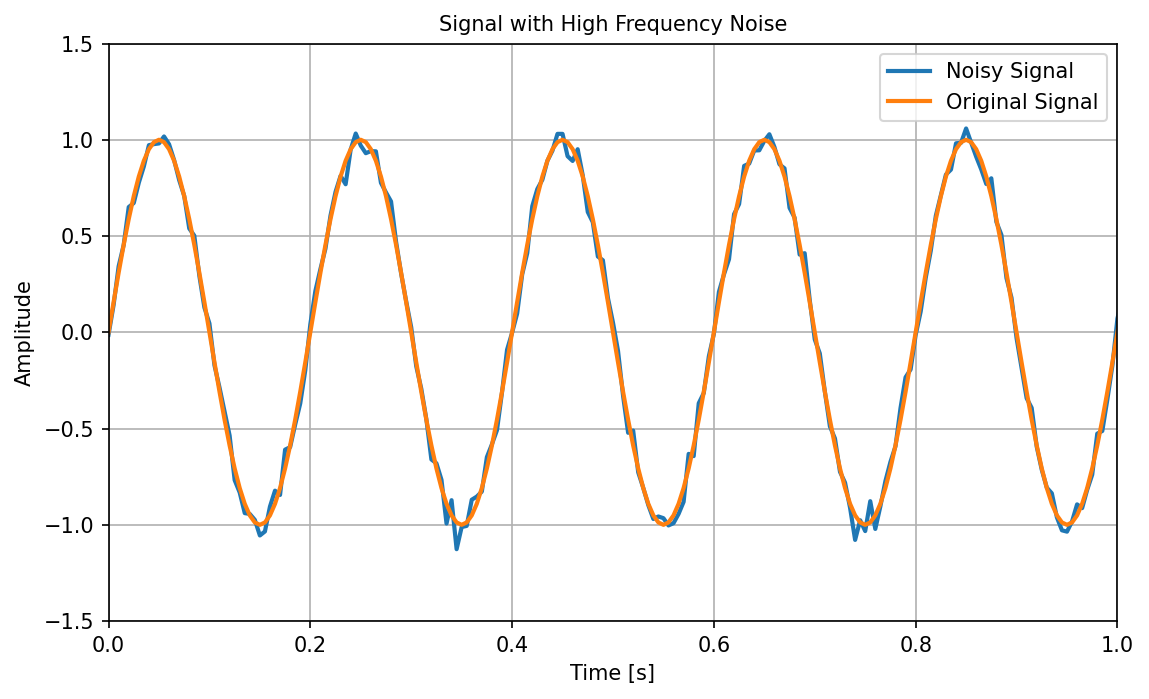

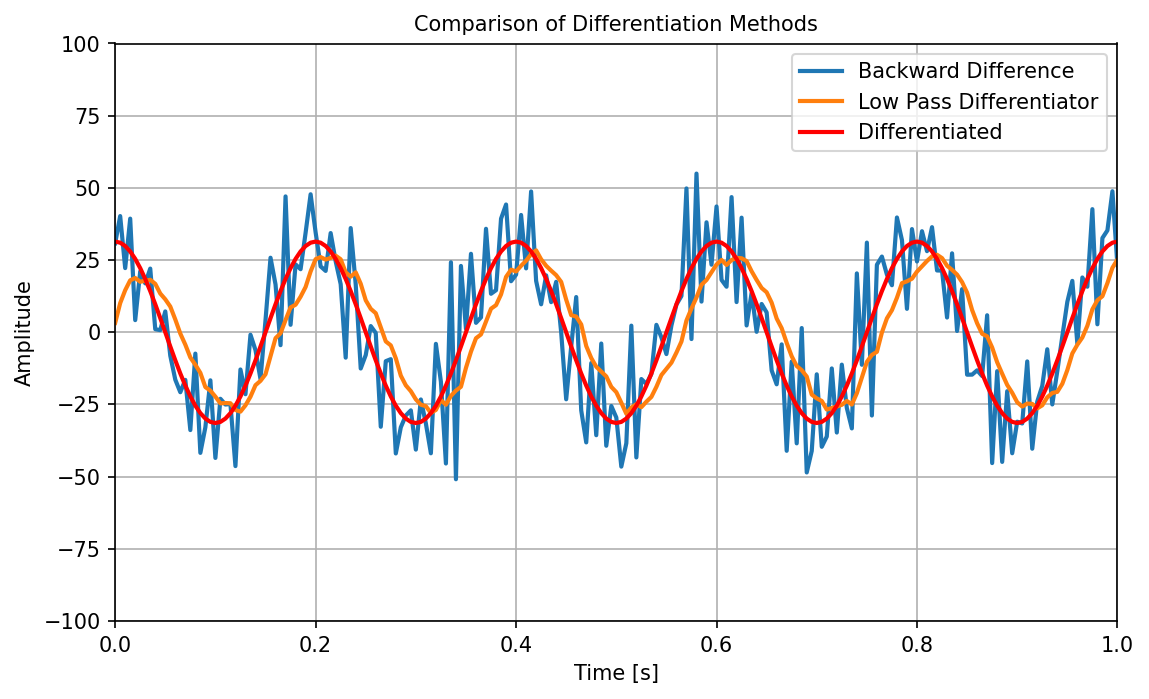

In [10]:
# Apply the filters to the noisy signal
backward_diff_result = backward_diff_filter.differentiate(noisy_signal)
low_pass_diff_result = low_pass_diff_filter.differentiate(noisy_signal)

# Plot the noisy signal
plt.figure(figsize=(8, 5))
plt.plot(t, noisy_signal, label='Noisy Signal')
plt.plot(t, signal, label='Original Signal', linewidth=2)
plt.xlabel('Time [s]')
plt.xlim(0,1)
plt.ylim(-1.5,1.5)
plt.ylabel('Amplitude')
plt.title('Signal with High Frequency Noise')
plt.legend()
plt.grid(True)
plt.show()

# Plot the results
plt.figure(figsize=(8, 5))
plt.plot(t[:-1], backward_diff_result, label='Backward Difference')
plt.plot(t[:-1], low_pass_diff_result, label='Low Pass Differentiator')
plt.plot(t, dsignal, 'r', label='Differentiated')
plt.xlim(0,1)
plt.ylim(-100,100)
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.title('Comparison of Differentiation Methods')
plt.legend()
plt.grid(True)
plt.show()

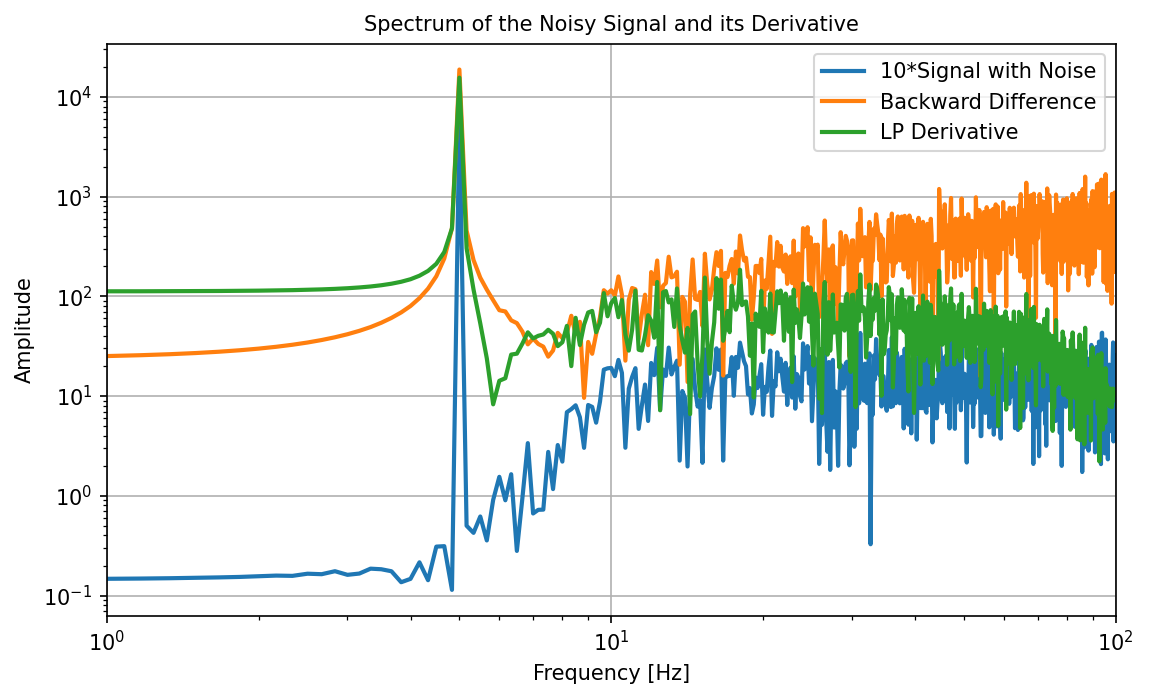

In [11]:
spectrum = np.fft.fft(noisy_signal)
spectrum_bw = np.fft.fft(backward_diff_result)
spectrum_lp = np.fft.fft(low_pass_diff_result)
Ns = len(spectrum)
Nf = Ns

# Compute the Fourier Transform of the derivative of the noisy signal
# Plot the spectrum of the noisy signal and its derivative
plt.figure(figsize=(8, 5))
plt.loglog(frequencies[:Ns//2], 1e1*np.abs(spectrum)[:Ns//2], label='10*Signal with Noise')
plt.loglog(frequencies[:Ns//2], np.abs(spectrum_bw)[:Ns//2], label='Backward Difference')
plt.loglog(frequencies[:Nf//2], np.abs(spectrum_lp)[:Nf//2], label='LP Derivative')
plt.xlim(1, 1/dt/2)  # Limit x-axis to positive frequencies
plt.xlabel('Frequency [Hz]')
plt.ylabel('Amplitude')
plt.title('Spectrum of the Noisy Signal and its Derivative')
plt.legend()
plt.grid(True)
plt.show()